In [62]:
import sys
sys.executable

'/home/gianl/miniconda3/envs/vm2/bin/python'

In [63]:
import os
os.getcwd()


'/home/gianl/Dokumente/projekte/VM2-RC-Modell-ui/notebooks'

In [64]:
import os, sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("PROJECT_ROOT =", PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

PROJECT_ROOT = /home/gianl/Dokumente/projekte/VM2-RC-Modell-ui


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path

from core.bootstrap import create_facade # imports the connection to the midlayer


In [66]:
PROJECT_ID = "rc-model-validation"
VARIANT_ID = "Val"
facade_Val = create_facade(PROJECT_ID, VARIANT_ID)

facade_Val.run_simulation(PROJECT_ID, VARIANT_ID)

Simulation finished.


RunReport(ok=True, run_id='latest', message='Simulation for project rc-model-validation and variant Val completed successfully.')

In [67]:
# load results
df_res_py = facade_Val._result.load_raw()
df_res_py = df_res_py.drop(columns=["temperature_outdoor_air"], axis=1)
df_res_py.head(5)

,temperature_air_room,temperature_in_glazing_north,temperature_in_glazing_east,temperature_in_glazing_south,temperature_in_glazing_west,temperature_out_glazing_north,temperature_out_glazing_east,temperature_out_glazing_south,temperature_out_glazing_west,temperature_in_frame_north,...,temperature_wall_s_4,temperature_wall_w_4,temperature_roof_4,temperature_floor_4,temperature_int_wall_4,temperature_int_ceiling_4,output_heating_power,output_cooling_power,output_lighting_electricity,output_equipment_electricity
datetime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,20.999935,19.124579,19.124579,19.124579,19.124579,0.262239,0.262239,0.262239,0.262239,14.716956,...,-0.188432,-0.189554,-0.292847,11.748916,21.111555,21.118699,1.909595e+07,0.0,-2.273737e-13,753.12
2019-01-01 01:00:00,20.999938,19.201088,19.201088,19.201088,19.201088,1.174009,1.174009,1.174009,1.174009,14.988643,...,0.742958,0.741893,0.643856,11.746305,21.065580,21.109155,1.825121e+07,0.0,-2.273737e-13,753.12
2019-01-01 02:00:00,20.999941,19.269740,19.269740,19.269740,19.269740,1.975606,1.975606,1.975606,1.975606,15.228565,...,1.562644,1.561633,1.468828,11.743680,21.026978,21.097564,1.748302e+07,0.0,-2.273737e-13,753.12
2019-01-01 03:00:00,20.999942,19.310989,19.310989,19.310989,19.310989,2.462928,2.462928,2.462928,2.462928,15.374049,...,2.064583,2.063624,1.977093,11.741045,20.994910,21.084854,1.691383e+07,0.0,-2.273737e-13,753.12
2019-01-01 04:00:00,20.999942,19.320672,19.320672,19.320672,19.320672,2.598231,2.598231,2.598231,2.598231,15.413086,...,2.207871,2.206961,2.125550,11.738402,20.968282,21.071687,1.664640e+07,0.0,-2.273737e-13,753.12


# load matlab result

In [68]:
# path to matlab results
mat_path = Path(PROJECT_ROOT) / 'projects' / 'rc-model-validation' / 'mat-reference' / 'matlab_ref_results.mat'

# load matlab results
mat_data = loadmat(mat_path, squeeze_me=True)

# Extract relevant output data from MATLAB structure
Q_c_ref = mat_data['output_cooling_power']
Q_h_ref = mat_data['output_heating_power']
El_ref = mat_data['output_lighting_electricity']
Eq_ref = mat_data['output_equipment_electricity']

# Create DataFrame for MATLAB outputs
df_outputs = pd.DataFrame({
    'output_heating_power': Q_h_ref,
    'output_cooling_power': Q_c_ref,
    'output_lighting_electricity': El_ref,
    'output_equipment_electricity': Eq_ref
})


try:
    row_names_all = df_res_py.columns.tolist()
    row_names = row_names_all[:-4]  # Exclude first and last four columns
except NameError:
    print("df_res_py is not defined.")
    
temp_mat_array = mat_data['output_temperatures']
num_rows_mat = temp_mat_array.shape[1]

if len(row_names) != num_rows_mat:
    print("Warning: Number of row names does not match number of rows in the MATLAB data.")
    print(f"Number of row names: {len(row_names)}, Number of rows in MATLAB data: {num_rows_mat}")
else:
    df_temp_outputs = pd.DataFrame(
        data=temp_mat_array,
        columns=row_names
    )

df_res_mat = pd.concat([df_temp_outputs, df_outputs], axis=1)
df_res_mat.head()


,temperature_air_room,temperature_in_glazing_north,temperature_in_glazing_east,temperature_in_glazing_south,temperature_in_glazing_west,temperature_out_glazing_north,temperature_out_glazing_east,temperature_out_glazing_south,temperature_out_glazing_west,temperature_in_frame_north,...,temperature_wall_s_4,temperature_wall_w_4,temperature_roof_4,temperature_floor_4,temperature_int_wall_4,temperature_int_ceiling_4,output_heating_power,output_cooling_power,output_lighting_electricity,output_equipment_electricity
0,20.905853,18.793906,18.793906,18.793906,18.793906,-0.713638,-0.713638,-0.713638,-0.713638,13.990463,...,-1.199977,-1.201227,-1.324237,11.744259,20.730805,20.772433,21063.686547,0.0,-2.273737e-13,753.12
1,20.908765,18.886626,18.886626,18.886626,18.886626,0.253663,0.253663,0.253663,0.253663,14.298536,...,-0.192939,-0.194127,-0.295613,11.741659,20.719788,20.765526,19995.501184,0.0,-2.273737e-13,753.12
2,20.911558,18.974430,18.974430,18.974430,18.974430,1.165840,1.165840,1.165840,1.165840,14.589330,...,0.738508,0.737377,0.641098,11.739059,20.712807,20.758921,19381.661872,0.0,-2.273737e-13,753.12
3,20.914053,19.051837,19.051837,19.051837,19.051837,1.967752,1.967752,1.967752,1.967752,14.845135,...,1.558268,1.557192,1.466090,11.736458,20.708659,20.752766,18813.129875,0.0,-2.273737e-13,753.12
4,20.915564,19.098664,19.098664,19.098664,19.098664,2.455275,2.455275,2.455275,2.455275,15.000477,...,2.060295,2.059270,1.974384,11.733857,20.706447,20.747101,18389.275320,0.0,-2.273737e-13,753.12


# Compare Python and Matlab code

In [69]:
df_res_mat.index = df_res_py.index

df_diff = df_res_py.subtract(df_res_mat, fill_value=0)
df_diff.head()

,temperature_air_room,temperature_in_glazing_north,temperature_in_glazing_east,temperature_in_glazing_south,temperature_in_glazing_west,temperature_out_glazing_north,temperature_out_glazing_east,temperature_out_glazing_south,temperature_out_glazing_west,temperature_in_frame_north,...,temperature_wall_s_4,temperature_wall_w_4,temperature_roof_4,temperature_floor_4,temperature_int_wall_4,temperature_int_ceiling_4,output_heating_power,output_cooling_power,output_lighting_electricity,output_equipment_electricity
datetime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,0.094083,0.330673,0.330673,0.330673,0.330673,0.975877,0.975877,0.975877,0.975877,0.726493,...,1.011545,1.011673,1.031389,0.004657,0.380750,0.346266,1.907488e+07,0.0,0.0,0.0
2019-01-01 01:00:00,0.091173,0.314463,0.314463,0.314463,0.314463,0.920347,0.920347,0.920347,0.920347,0.690108,...,0.935897,0.936021,0.939469,0.004645,0.345792,0.343629,1.823121e+07,0.0,0.0,0.0
2019-01-01 02:00:00,0.088383,0.295310,0.295310,0.295310,0.295310,0.809765,0.809765,0.809765,0.809765,0.639235,...,0.824136,0.824256,0.827730,0.004621,0.314171,0.338642,1.746363e+07,0.0,0.0,0.0
2019-01-01 03:00:00,0.085889,0.259152,0.259152,0.259152,0.259152,0.495175,0.495175,0.495175,0.495175,0.528914,...,0.506315,0.506432,0.511003,0.004587,0.286252,0.332088,1.689502e+07,0.0,0.0,0.0
2019-01-01 04:00:00,0.084379,0.222008,0.222008,0.222008,0.222008,0.142956,0.142956,0.142956,0.142956,0.412609,...,0.147577,0.147691,0.151167,0.004545,0.261835,0.324586,1.662801e+07,0.0,0.0,0.0


Maximum Absolute Error $E_{max}$:

In [70]:
max_abs_err_temp_room= np.max(np.abs(df_diff["temperature_air_room"]))
max_abs_err_heating_power= np.max(np.abs(df_diff["output_heating_power"]))
max_abs_err_cooling_power= np.max(np.abs(df_diff["output_cooling_power"]))
max_abs_err_lighting_electricity= np.max(np.abs(df_diff["output_lighting_electricity"]))
max_abs_err_equipment_electricity= np.max(np.abs(df_diff["output_equipment_electricity"]))
print(f"Max absolute error in room temperature: {max_abs_err_temp_room:.4e} °C")
print(f"Max absolute error in heating power: {max_abs_err_heating_power:.4e} W")
print(f"Max absolute error in cooling power: {max_abs_err_cooling_power:.4e} W")
print(f"Max absolute error in lighting electricity: {max_abs_err_lighting_electricity:.4e} W")
print(f"Max absolute error in equipment electricity: {max_abs_err_equipment_electricity:.4e} W")

Max absolute error in room temperature: 2.0899e+01 °C
Max absolute error in heating power: 2.6796e+07 W
Max absolute error in cooling power: 7.4922e+06 W
Max absolute error in lighting electricity: 2.5418e+04 W
Max absolute error in equipment electricity: 6.7781e+03 W


Root Mean Square Error $E_{RMSE}$:

In [71]:
rmse_temp_room= np.sqrt(np.mean(df_diff["temperature_air_room"]**2))
rmse_heating_power= np.sqrt(np.mean(df_diff["output_heating_power"]**2))
rmse_cooling_power= np.sqrt(np.mean(df_diff["output_cooling_power"]**2))
rmse_lighting_electricity= np.sqrt(np.mean(df_diff["output_lighting_electricity"]**2))
rmse_equipment_electricity= np.sqrt(np.mean(df_diff["output_equipment_electricity"]**2))
print(f"RMSE in room temperature: {rmse_temp_room:.4e} °C")
print(f"RMSE in heating power: {rmse_heating_power:.4e} W")
print(f"RMSE in cooling power: {rmse_cooling_power:.4e} W")
print(f"RMSE in lighting electricity: {rmse_lighting_electricity:.4e} W")
print(f"RMSE in equipment electricity: {rmse_equipment_electricity:.4e} W")

RMSE in room temperature: 1.6352e+00 °C
RMSE in heating power: 1.1216e+07 W
RMSE in cooling power: 3.9937e+05 W
RMSE in lighting electricity: 9.0374e+03 W
RMSE in equipment electricity: 1.4006e+03 W


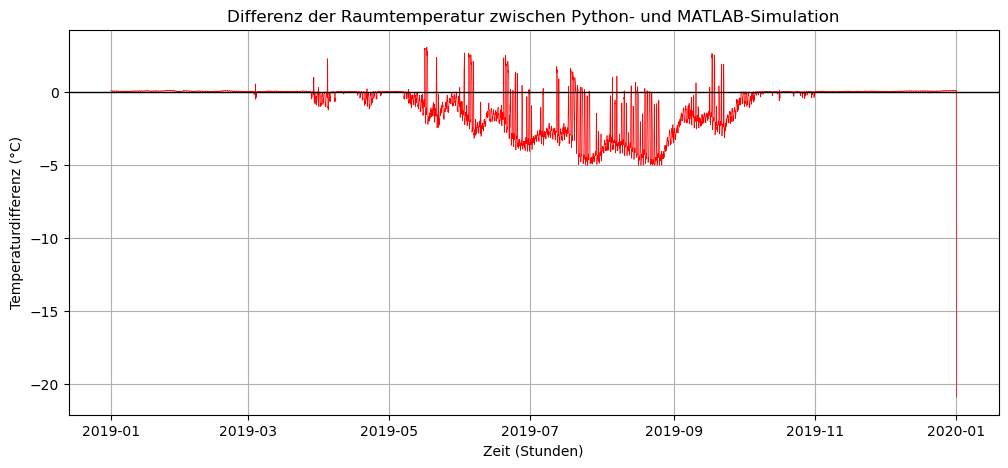

In [72]:
plt.figure(figsize=(12, 5))
plt.plot(df_res_py.index, df_diff["temperature_air_room"], label='Differenz (Python - MATLAB)', color='red', linewidth=0.5)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title('Differenz der Raumtemperatur zwischen Python- und MATLAB-Simulation')
plt.xlabel('Zeit (Stunden)')
plt.ylabel('Temperaturdifferenz (°C)')
plt.grid(True)
plt.show()
